In [4]:
!pip install pyspark findspark -q

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CuboBigDataTenis") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

In [6]:
fact_serve = spark.read.csv("fact_serve.csv", header=True, inferSchema=True)
dim_player = spark.read.csv("dim_player.csv", header=True, inferSchema=True)
dim_surface = spark.read.csv("dim_surface.csv", header=True, inferSchema=True)
dim_time = spark.read.csv("dim_time.csv", header=True, inferSchema=True)
dim_tournament = spark.read.csv("dim_tournament.csv", header=True, inferSchema=True)

In [7]:
fact_serve = spark.read.csv("fact_serve.csv", header=True, inferSchema=True)
dim_player = spark.read.csv("dim_player.csv", header=True, inferSchema=True)
dim_surface = spark.read.csv("dim_surface.csv", header=True, inferSchema=True)
dim_time = spark.read.csv("dim_time.csv", header=True, inferSchema=True)
dim_tournament = spark.read.csv("dim_tournament.csv", header=True, inferSchema=True)

In [8]:
fact_serve.show(5)
dim_player.show(5)

+----------+-----------+--------+--------------+----+-------------+---------------+
|player_key|surface_key|time_key|tournament_key|aces|double_faults|first_serve_pct|
+----------+-----------+--------+--------------+----+-------------+---------------+
|         1|          1|       1|             1|12.0|          2.0|        76.5625|
|       201|          1|       1|             1|12.0|          2.0|        76.5625|
|       216|          1|       1|             1|12.0|          2.0|        76.5625|
|       300|          1|       1|             1|12.0|          2.0|        76.5625|
|       419|          1|       1|             1|12.0|          2.0|        76.5625|
+----------+-----------+--------+--------------+----+-------------+---------------+
only showing top 5 rows
+--------------------+------+----+----------+
|         player_name|height| age|player_key|
+--------------------+------+----+----------+
|      Novak Djokovic| 188.0|32.6|         1|
|Roberto Bautista ...| 183.0|31.7|  

In [9]:
serve_cube = fact_serve \
    .join(dim_player, on="player_key", how="left") \
    .join(dim_surface, on="surface_key", how="left") \
    .join(dim_time, on="time_key", how="left") \
    .join(dim_tournament, on="tournament_key", how="left")

In [10]:
serve_cube.show(5)

+--------------+--------+-----------+----------+----+-------------+---------------+--------------+------+----+-------+------------+----+-----+---+-----------+------------+
|tournament_key|time_key|surface_key|player_key|aces|double_faults|first_serve_pct|   player_name|height| age|surface|tourney_date|year|month|day|day_of_week|tourney_name|
+--------------+--------+-----------+----------+----+-------------+---------------+--------------+------+----+-------+------------+----+-----+---+-----------+------------+
|             1|       1|          1|         1|12.0|          2.0|        76.5625|Novak Djokovic| 188.0|32.6|   Hard|  2020-01-06|2020|    1|  6|     Monday|     Atp Cup|
|             1|       1|          1|       201|12.0|          2.0|        76.5625|Novak Djokovic| 188.0|32.7|   Hard|  2020-01-06|2020|    1|  6|     Monday|     Atp Cup|
|             1|       1|          1|       216|12.0|          2.0|        76.5625|Novak Djokovic| 188.0|33.2|   Hard|  2020-01-06|2020|    

In [11]:
serve_cube.printSchema()

root
 |-- tournament_key: integer (nullable = true)
 |-- time_key: integer (nullable = true)
 |-- surface_key: integer (nullable = true)
 |-- player_key: integer (nullable = true)
 |-- aces: double (nullable = true)
 |-- double_faults: double (nullable = true)
 |-- first_serve_pct: double (nullable = true)
 |-- player_name: string (nullable = true)
 |-- height: double (nullable = true)
 |-- age: double (nullable = true)
 |-- surface: string (nullable = true)
 |-- tourney_date: date (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- tourney_name: string (nullable = true)



In [12]:
serve_cube.createOrReplaceTempView("serve_cube")

In [13]:
from pyspark.sql.functions import when, col

serve_cube = serve_cube.withColumn(
    "height_group",
    when(col("height") < 180, "<180")
    .when((col("height") >= 180) & (col("height") < 190), "180-190")
    .when((col("height") >= 190) & (col("height") < 200), "190-200")
    .otherwise("200+")
)

serve_cube.createOrReplaceTempView("serve_cube")

In [14]:
q1 = spark.sql("""
SELECT
    height_group,
    ROUND(AVG(aces), 2) AS avg_aces
FROM serve_cube
GROUP BY height_group
ORDER BY avg_aces DESC
""")

q1.show()

+------------+--------+
|height_group|avg_aces|
+------------+--------+
|        200+|   17.27|
|     190-200|    8.64|
|     180-190|    5.38|
|        <180|    2.87|
+------------+--------+



In [15]:
q2 = spark.sql("""
SELECT
    surface,
    height_group,
    ROUND(AVG(aces), 2) AS avg_aces
FROM serve_cube
GROUP BY surface, height_group
ORDER BY surface, avg_aces DESC
""")

q2.show()

+-------+------------+--------+
|surface|height_group|avg_aces|
+-------+------------+--------+
|   Clay|        200+|   11.64|
|   Clay|     190-200|    5.41|
|   Clay|     180-190|    3.76|
|   Clay|        <180|    1.82|
|  Grass|     180-190|    18.0|
|  Grass|        <180|     8.0|
|   Hard|        200+|   18.14|
|   Hard|     190-200|    9.51|
|   Hard|     180-190|    6.09|
|   Hard|        <180|    3.24|
+-------+------------+--------+



In [16]:
q2_pd = q2.toPandas()

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

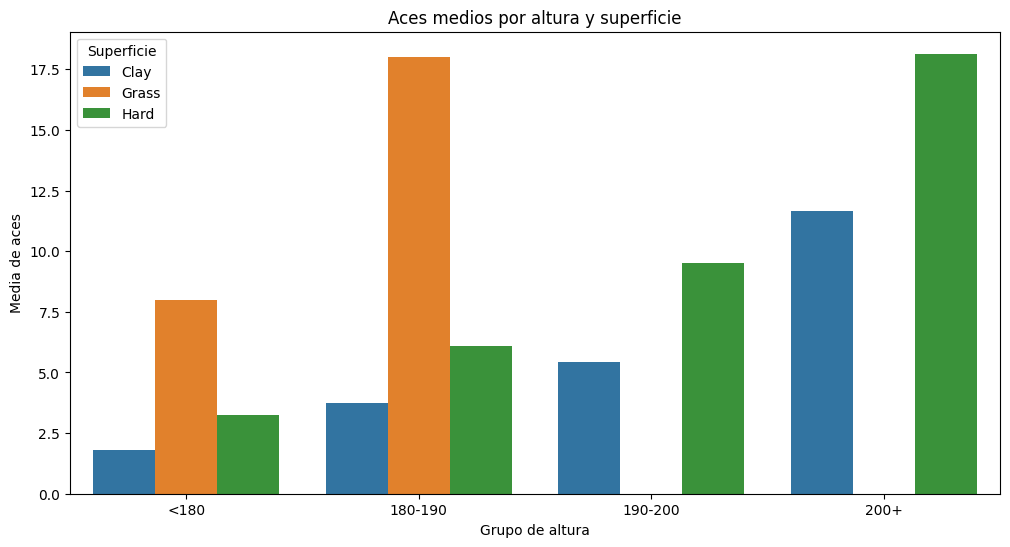

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=q2_pd,
    x="height_group",
    y="avg_aces",
    hue="surface",
    order=["<180", "180-190", "190-200", "200+"]
)

plt.title("Aces medios por altura y superficie")
plt.xlabel("Grupo de altura")
plt.ylabel("Media de aces")

plt.legend(title="Superficie")

plt.show()

In [19]:
spark.sql("""
SELECT
    surface,
    height_group,
    COUNT(*) AS num_registros,
    ROUND(AVG(aces), 2) AS avg_aces
FROM serve_cube
GROUP BY surface, height_group
ORDER BY surface, height_group
""").show(50)

+-------+------------+-------------+--------+
|surface|height_group|num_registros|avg_aces|
+-------+------------+-------------+--------+
|   Clay|     180-190|         2278|    3.76|
|   Clay|     190-200|          779|    5.41|
|   Clay|        200+|           47|   11.64|
|   Clay|        <180|          265|    1.82|
|  Grass|     180-190|            2|    18.0|
|  Grass|        <180|            1|     8.0|
|   Hard|     180-190|         5120|    6.09|
|   Hard|     190-200|         2899|    9.51|
|   Hard|        200+|          302|   18.14|
|   Hard|        <180|          739|    3.24|
+-------+------------+-------------+--------+



In [20]:
q2_pd.pivot(
    index="height_group",
    columns="surface",
    values="avg_aces"
)

surface,Clay,Grass,Hard
height_group,,,
180-190,3.76,18.0,6.09
190-200,5.41,NaN,9.51
200+,11.64,NaN,18.14
<180,1.82,8.0,3.24


In [21]:
q3 = spark.sql("""
SELECT
    height_group,
    ROUND(AVG(double_faults), 2) AS avg_double_faults
FROM serve_cube
GROUP BY height_group
ORDER BY avg_double_faults DESC
""")

q3.show()

+------------+-----------------+
|height_group|avg_double_faults|
+------------+-----------------+
|     190-200|             3.38|
|        200+|             3.19|
|     180-190|             2.84|
|        <180|              2.5|
+------------+-----------------+



In [22]:
q3_pd = q3.toPandas()

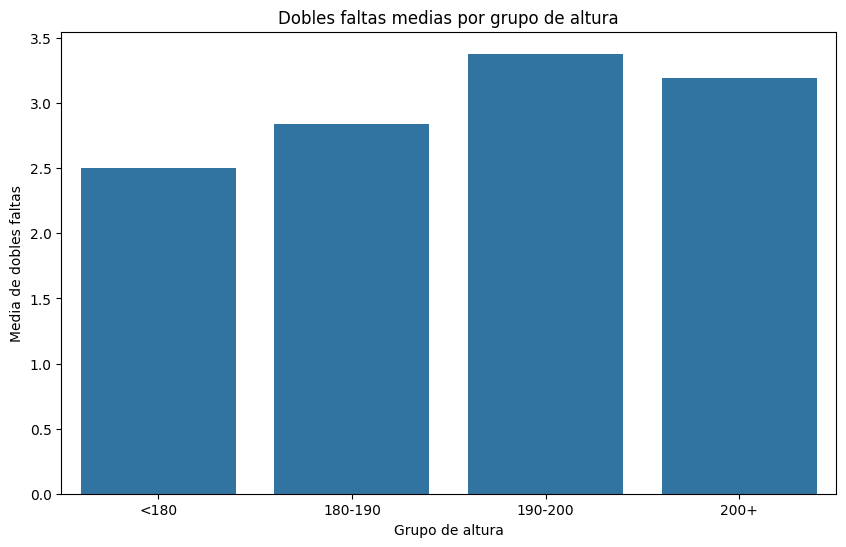

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=q3_pd,
    x="height_group",
    y="avg_double_faults",
    order=["<180", "180-190", "190-200", "200+"]
)

plt.title("Dobles faltas medias por grupo de altura")
plt.xlabel("Grupo de altura")
plt.ylabel("Media de dobles faltas")

plt.show()

In [24]:
q4 = spark.sql("""
SELECT
    surface,
    ROUND(AVG(first_serve_pct), 2) AS avg_first_serve
FROM serve_cube
GROUP BY surface
ORDER BY avg_first_serve DESC
""")

q4.show()

+-------+---------------+
|surface|avg_first_serve|
+-------+---------------+
|  Grass|          63.82|
|   Hard|           62.2|
|   Clay|          62.17|
+-------+---------------+



In [25]:
q4_pd = q4.toPandas()

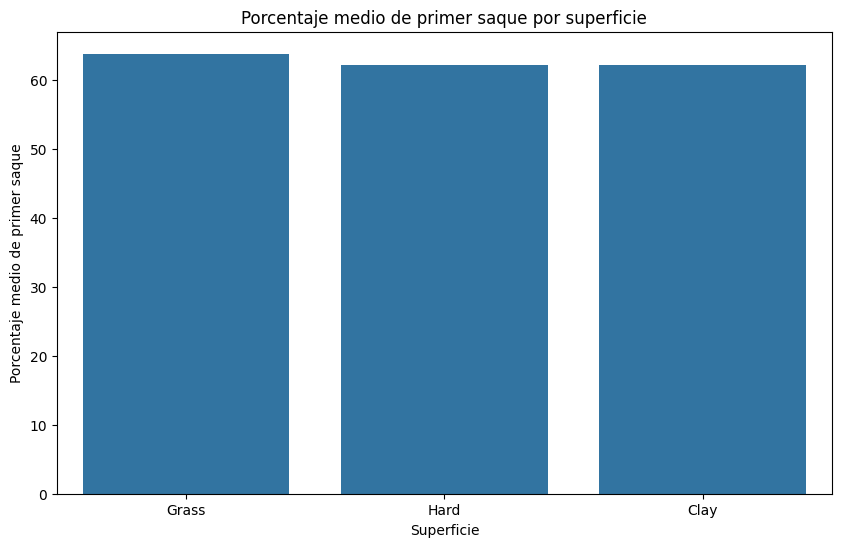

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=q4_pd,
    x="surface",
    y="avg_first_serve"
)

plt.title("Porcentaje medio de primer saque por superficie")
plt.xlabel("Superficie")
plt.ylabel("Porcentaje medio de primer saque")

plt.show()

In [27]:
q5 = spark.sql("""
SELECT
    tourney_name,
    ROUND(AVG(aces), 2) AS avg_aces
FROM serve_cube
GROUP BY tourney_name
ORDER BY avg_aces DESC
LIMIT 10
""")

q5.show()

+--------------------+--------+
|        tourney_name|avg_aces|
+--------------------+--------+
|Davis Cup WG1 PO:...|   14.67|
|     Australian Open|   10.19|
|Davis Cup QLS R1:...|    9.77|
|             Us Open|     9.3|
|Davis Cup WG1 PO:...|    8.79|
|                Pune|    8.56|
|Davis Cup QLS R1:...|    8.45|
|       St Petersburg|    8.33|
|            Adelaide|    8.32|
|            Auckland|    7.98|
+--------------------+--------+



In [28]:
q5_pd = q5.toPandas()

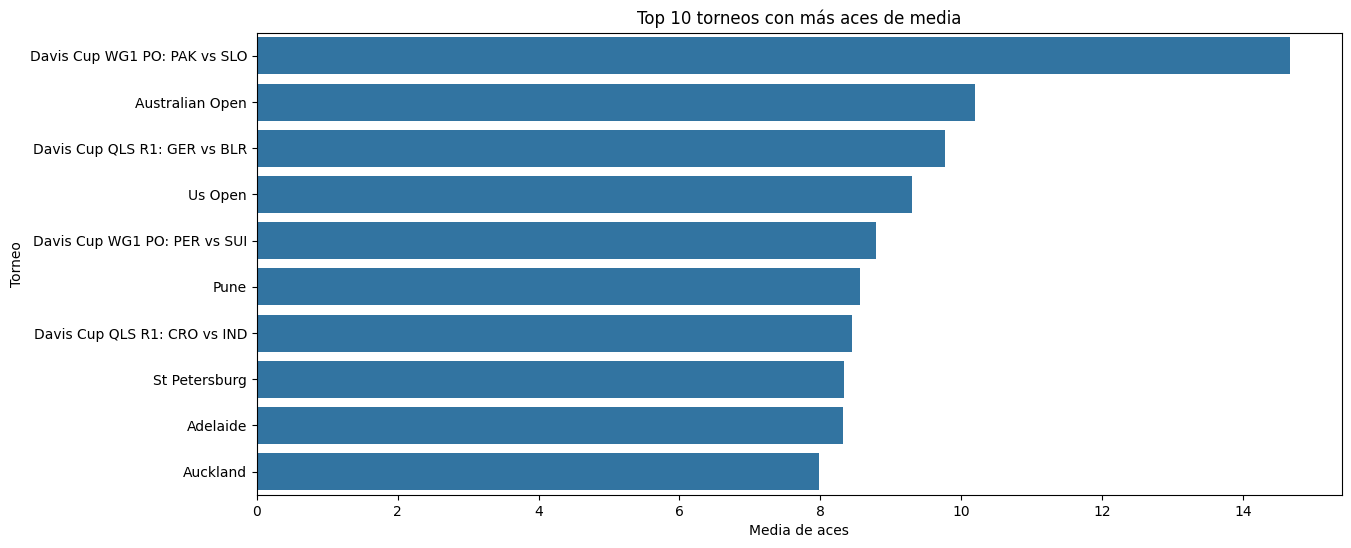

In [29]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=q5_pd,
    x="avg_aces",
    y="tourney_name"
)

plt.title("Top 10 torneos con más aces de media")
plt.xlabel("Media de aces")
plt.ylabel("Torneo")

plt.show()